# Sampling

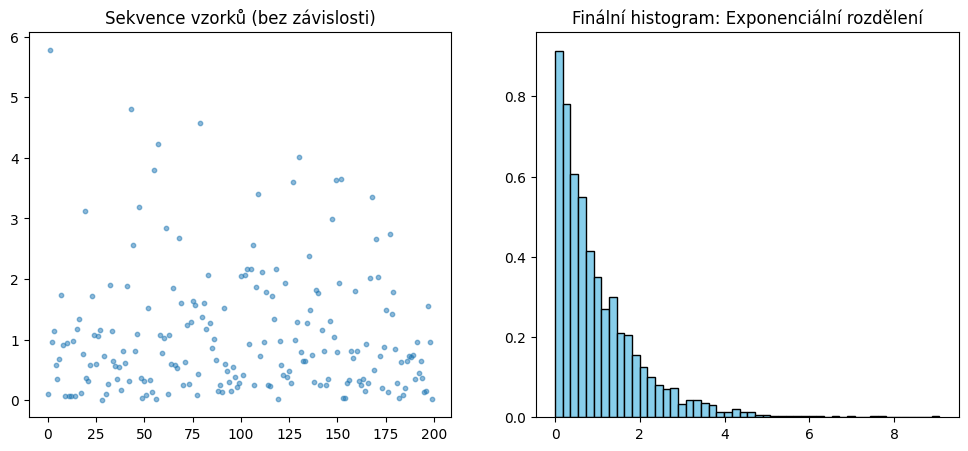

In [18]:
import numpy as np
import matplotlib.pyplot as plt

# Cíl: Exponenciální rozdělení (lambda = 1.0)
n_samples = 5000
u = np.random.uniform(0, 1, n_samples)
x = -np.log(1 - u)

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Pohyb parametrů (zde jen pořadí generování)
ax[0].scatter(range(200), x[:200], s=10, alpha=0.5)
ax[0].set_title("Sekvence vzorků (bez závislosti)")

# Finální histogram
ax[1].hist(x, bins=50, density=True, color='skyblue', edgecolor='black')
ax[1].set_title("Finální histogram: Exponenciální rozdělení")
plt.show()

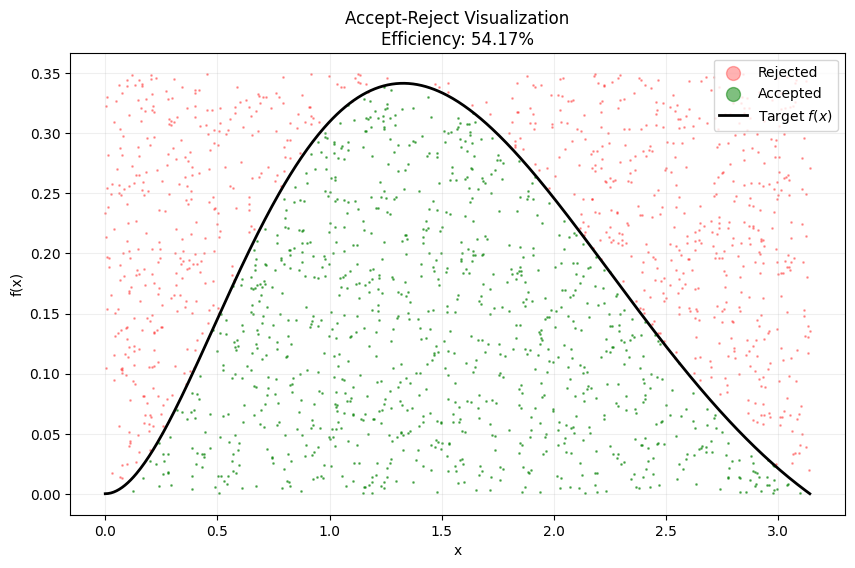

In [19]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Cílová funkce
def f(x):
    return x * np.sin(x) * np.exp(-x)

low, high = 0, np.pi
max_f = 0.35  # Max f(x) na intervalu
M_val = max_f   # Výška obdélníku (protože g(x) je uniformní)

# 2. Simulace
n_target = 1000
accepted_x, accepted_y = [], []
rejected_x, rejected_y = [], []

while len(accepted_x) < n_target:
    # Generujeme bod v obdélníku [0, pi] x [0, M_val]
    x_cand = np.random.uniform(low, high)
    y_cand = np.random.uniform(0, M_val)
    
    if y_cand <= f(x_cand):
        accepted_x.append(x_cand)
        accepted_y.append(y_cand)
    else:
        rejected_x.append(x_cand)
        rejected_y.append(y_cand)

# 3. Vizualizace
fig, ax = plt.subplots(figsize=(10, 6))

# Vykreslení zamítnutých a přijatých bodů
ax.scatter(rejected_x, rejected_y, color='red', s=1, alpha=0.3, label='Rejected')
ax.scatter(accepted_x, accepted_y, color='green', s=1, alpha=0.5, label='Accepted')

# Teoretická křivka f(x) - v tomto případě nenormalizovaná
x_plot = np.linspace(low, high, 500)
ax.plot(x_plot, f(x_plot), color='black', lw=2, label='Target $f(x)$')

# Nastavení grafu
efficiency = len(accepted_x) / (len(accepted_x) + len(rejected_x))
ax.set_title(f'Accept-Reject Visualization\nEfficiency: {efficiency:.2%}')
ax.set_xlabel('x')
ax.set_ylabel('f(x)')
ax.legend(loc='upper right', markerscale=10)
ax.grid(alpha=0.2)

plt.show()

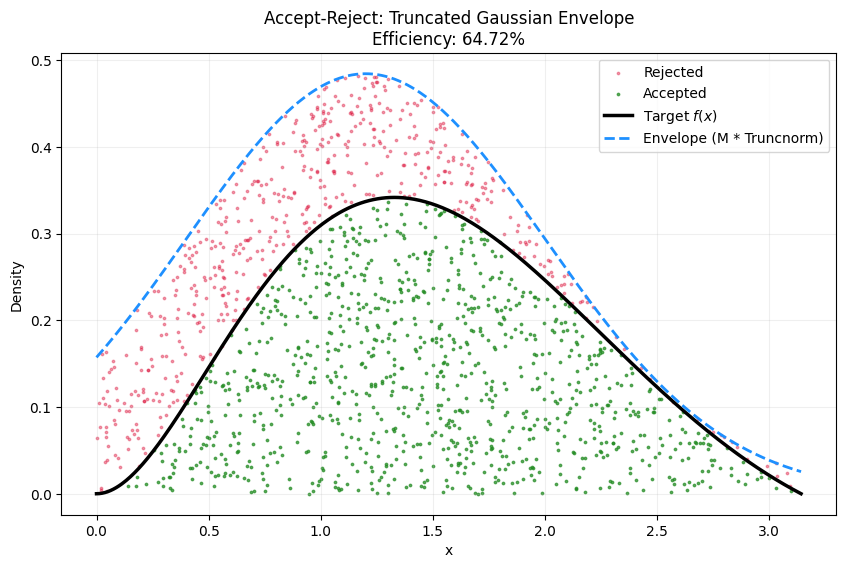

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import truncnorm

# 1. Definice cílové funkce f(x)
def f(x):
    return x * np.sin(x) * np.exp(-x)

# 2. Parametry pro Truncated Gaussian (Proposal g)
low, high = 0, np.pi
mu_g, sigma_g = 1.2, 0.8

# Přepočet hranic pro scipy.stats.truncnorm
a, b = (low - mu_g) / sigma_g, (high - mu_g) / sigma_g

# 3. Nalezení konstanty M
# Potřebujeme M takové, aby f(x) <= M * g(x)
# g(x) je v tomto případě truncnorm.pdf
x_vals = np.linspace(low, high, 500)
# M musí být alespoval max(f(x) / g(x))
ratio = f(x_vals) / truncnorm.pdf(x_vals, a, b, loc=mu_g, scale=sigma_g)
M = np.max(ratio) * 1.05  # 5% rezerva pro jistotu

# 4. Simulace
n_target = 1000
accepted_x, accepted_y = [], []
rejected_x, rejected_y = [], []

while len(accepted_x) < n_target:
    # Generujeme kandidáta přímo z oříznuté Gaussovky (vždy v intervalu [0, pi])
    x_cand = truncnorm.rvs(a, b, loc=mu_g, scale=sigma_g)
    
    # Návrhová hustota v bodě x_cand
    g_val = truncnorm.pdf(x_cand, a, b, loc=mu_g, scale=sigma_g)
    
    # Generujeme náhodnou výšku u pod obalovou funkcí M * g(x)
    u = np.random.uniform(0, M * g_val)
    
    if u <= f(x_cand):
        accepted_x.append(x_cand)
        accepted_y.append(u)
    else:
        rejected_x.append(x_cand)
        rejected_y.append(u)

# 5. Vizualizace
fig, ax = plt.subplots(figsize=(10, 6))

# Vykreslení pokusů
ax.scatter(rejected_x, rejected_y, color='crimson', s=3, alpha=0.4, label='Rejected')
ax.scatter(accepted_x, accepted_y, color='forestgreen', s=3, alpha=0.7, label='Accepted')

# Vykreslení křivek
ax.plot(x_vals, f(x_vals), color='black', lw=2.5, label='Target $f(x)$')
ax.plot(x_vals, M * truncnorm.pdf(x_vals, a, b, loc=mu_g, scale=sigma_g), 
        color='dodgerblue', linestyle='--', lw=2, label='Envelope (M * Truncnorm)')

# Statistiky
total_attempts = len(accepted_x) + len(rejected_x)
eff = len(accepted_x) / total_attempts

ax.set_title(f'Accept-Reject: Truncated Gaussian Envelope\nEfficiency: {eff:.2%}')
ax.set_xlabel('x')
ax.set_ylabel('Density')
ax.legend()
ax.grid(alpha=0.2)

plt.show()

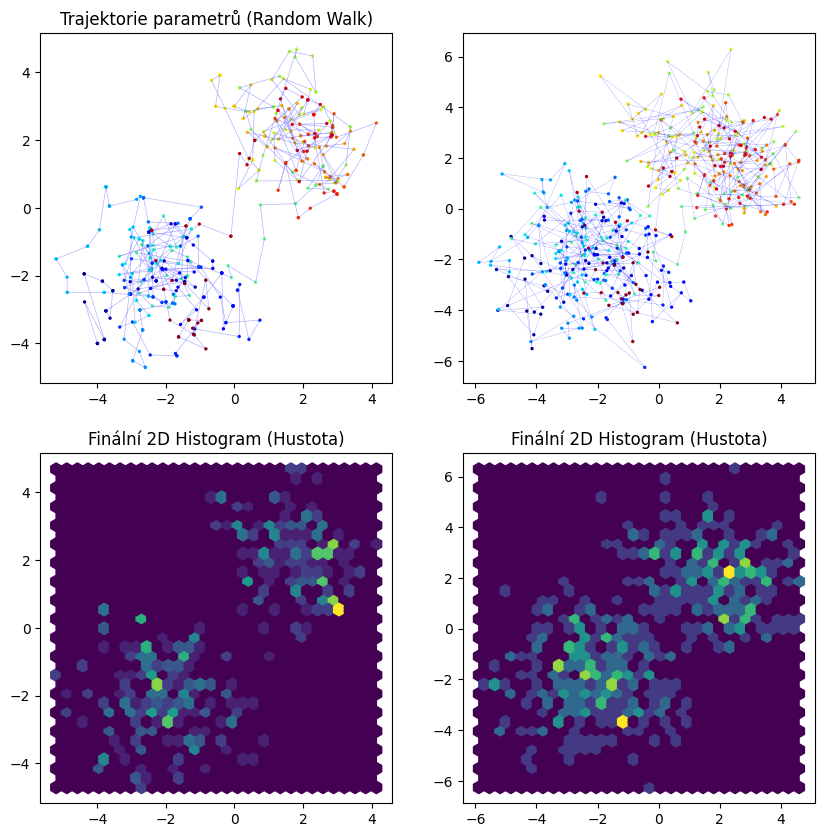

In [21]:
import numpy as np
import matplotlib.pyplot as plt

def log_target(p): # Bimodální 2D povrch
    return np.log(2*np.exp(-0.5*np.sum((p-2)**2)) + np.exp(-0.5*np.sum((p+2)**2)))

n_iter = 500
samples = [np.array([-4.0, -4.0])]
trajectory = []
bad_one = []
for _ in range(n_iter):
    prop = samples[-1] + np.random.normal(0, 0.8, 2)
    trajectory.append(prop)
    if np.log(np.random.rand()) < log_target(prop) - log_target(samples[-1]):
        samples.append(prop)
        bad_one.append(prop)
    else:
        bad_one.append(prop)
        samples.append(samples[-1])

s = np.array(samples)
fig, ax = plt.subplots(2, 2, figsize=(10, 10))

trajectory = np.array(trajectory)
bad_one = np.array(bad_one)

# Cesta parametrů
ax[0,0].plot(s[:, 0], s[:, 1], 'b-', alpha=0.3, lw=0.5)
ax[0,0].scatter(s[:, 0], s[:, 1], c=range(len(s)), cmap='jet', s=2)
ax[0,0].set_title("Trajektorie parametrů (Random Walk)")

ax[0,1].scatter(bad_one[:, 0], bad_one[:, 1], c=range(len(bad_one)), cmap='jet', s=2)
ax[0,1].plot(trajectory[:, 0], trajectory[:, 1], 'b-', lw=0.1)


# Finální histogram
ax[1,0].hexbin(s[:, 0], s[:, 1], gridsize=30, cmap='viridis')
ax[1,0].set_title("Finální 2D Histogram (Hustota)")


ax[1,1].hexbin(trajectory[:, 0], trajectory[:, 1], gridsize=30, cmap='viridis')
ax[1,1].set_title("Finální 2D Histogram (Hustota)")

plt.show()

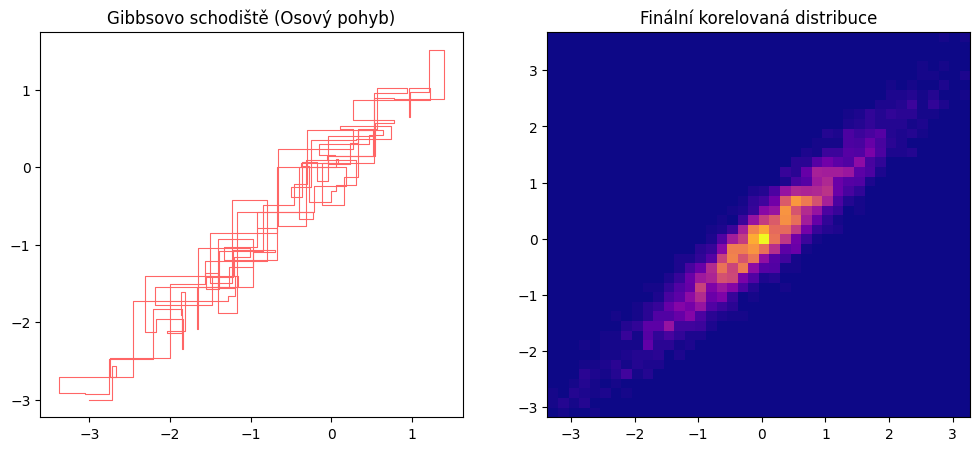

In [22]:
import numpy as np
import matplotlib.pyplot as plt

n_iter = 2000
rho = 0.95
samples = [[-3.0, -3.0]]
for _ in range(n_iter):
    curr_y = samples[-1][1]
    new_x = np.random.normal(rho * curr_y, np.sqrt(1 - rho**2))
    samples.append([new_x, curr_y]) # Horizontální krok
    new_y = np.random.normal(rho * new_x, np.sqrt(1 - rho**2))
    samples.append([new_x, new_y]) # Vertikální krok

s = np.array(samples)
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Cesta parametrů (schody)
ax[0].plot(s[:200, 0], s[:200, 1], 'r-', lw=0.8, alpha=0.6)
ax[0].set_title("Gibbsovo schodiště (Osový pohyb)")

# Finální histogram
ax[1].hist2d(s[:,0], s[:,1], bins=40, cmap='plasma')
ax[1].set_title("Finální korelovaná distribuce")
plt.show()

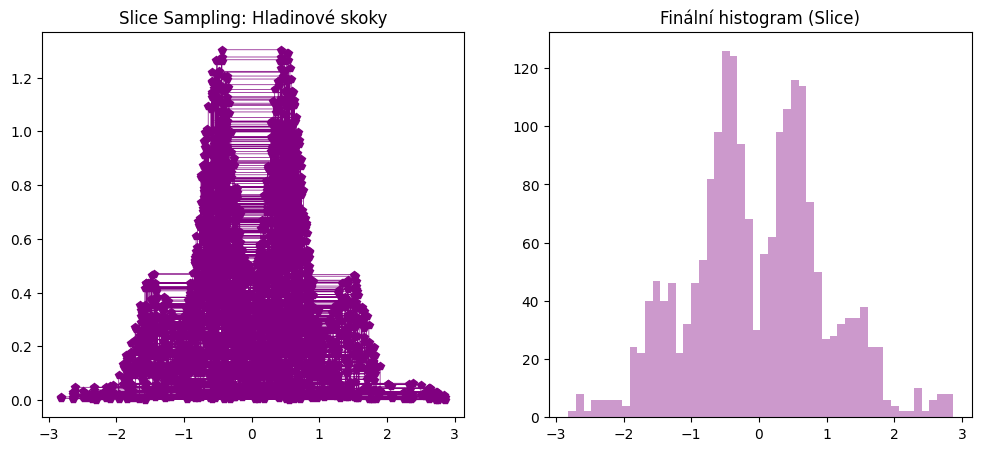

In [23]:
import numpy as np
import matplotlib.pyplot as plt

def target(x): return np.exp(-x**2/2) * (np.sin(3*x)**2 + 0.5)

x_curr = 1.0
path = []
for _ in range(1000):
    y_slice = np.random.uniform(0, target(x_curr))
    path.append([x_curr, y_slice]) # Vertikální krok
    x_curr = np.random.uniform(-3, 3) # Zjednodušený horizontální skok
    while target(x_curr) < y_slice:
        x_curr = np.random.uniform(-3, 3)
    path.append([x_curr, y_slice]) # Horizontální krok

s = np.array(path)
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Cesta parametrů (svislé a vodorovné čáry)
ax[0].plot(s[:, 0], s[:, 1], 'p-', lw=0.5, color='purple')
ax[0].set_title("Slice Sampling: Hladinové skoky")

# Finální histogram
ax[1].hist(s[:,0], bins=50, color='purple', alpha=0.4)
ax[1].set_title("Finální histogram (Slice)")
plt.show()

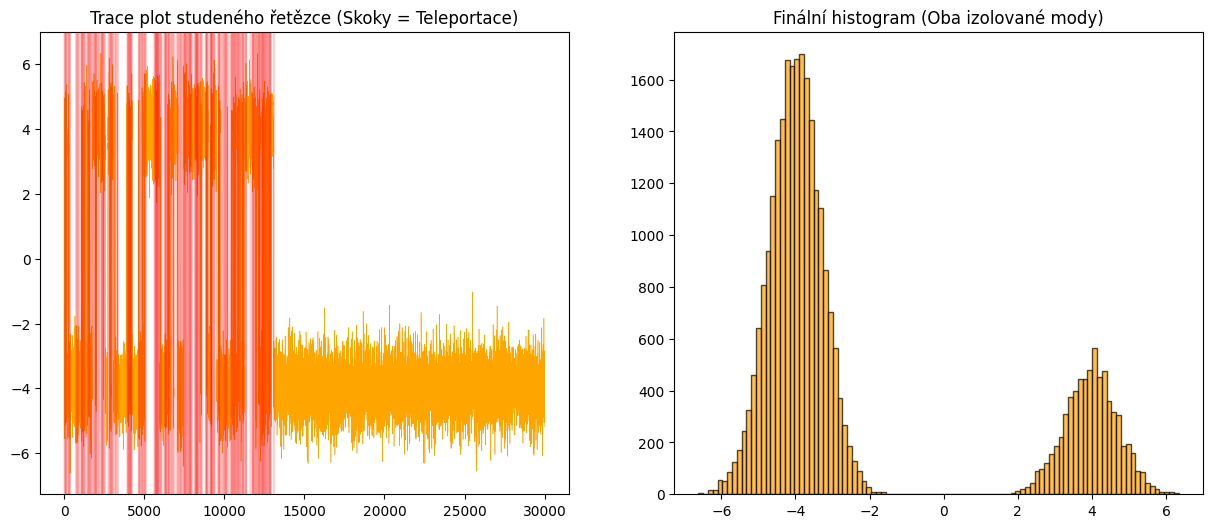

In [24]:
import numpy as np
import matplotlib.pyplot as plt

# Preamble: Dvě izolované Gaussovky daleko od sebe
def log_p(x, T=1):
    # Cíl: N(-4, 0.5) a N(4, 0.5)
    p1 = np.exp(-0.5 * (x - 4)**2 / 0.5)
    p2 = np.exp(-0.5 * (x + 4)**2 / 0.5)
    return np.log(1e-10 + p1 + p2) / T

# --- PARALLEL TEMPERING ---
n_iter = 30000
x_cold = 4.0   # Studený řetězec (cílový)
x_hot = -8.0   # Horký řetězec (průzkumník)
T_hot = 10.0

history_cold = []
swaps = []

for i in range(n_iter):
    # 1. Standardní MH krok pro oba
    for x, T in [(x_cold, 1), (x_hot, T_hot)]:
        prop = x + np.random.normal(0, 1.0)
        if np.log(np.random.rand()) < log_p(prop, T) - log_p(x, T):
            if T == 1: x_cold = prop
            else: x_hot = prop
            
    # 2. Swap mechanismus (každých 10 kroků)
    if i % 10 == 0:
        # Pravděpodobnost výměny na základě poměru energií
        a = (log_p(x_hot, 1) + log_p(x_cold, T_hot)) - (log_p(x_cold, 1) + log_p(x_hot, T_hot))
        if np.log(np.random.rand()) < a:
            x_cold, x_hot = x_hot, x_cold
            swaps.append(i)
    
    history_cold.append(x_cold)

fig, ax = plt.subplots(1, 2, figsize=(15, 6))

# Cesta parametrů: Trace plot se svislými skoky (teleportace)
ax[0].plot(history_cold, lw=0.4, color='orange')
for s in swaps: ax[0].axvline(s, color='red', alpha=0.1)
ax[0].set_title("Trace plot studeného řetězce (Skoky = Teleportace)")

# Finální histogram: Oba vrcholy jsou rovnoměrně zastoupeny
ax[1].hist(history_cold, bins=100, color='orange', alpha=0.7, edgecolor='black')
ax[1].set_title("Finální histogram (Oba izolované mody)")
plt.show()

Míra přijetí (Acceptance rate): 8.22%


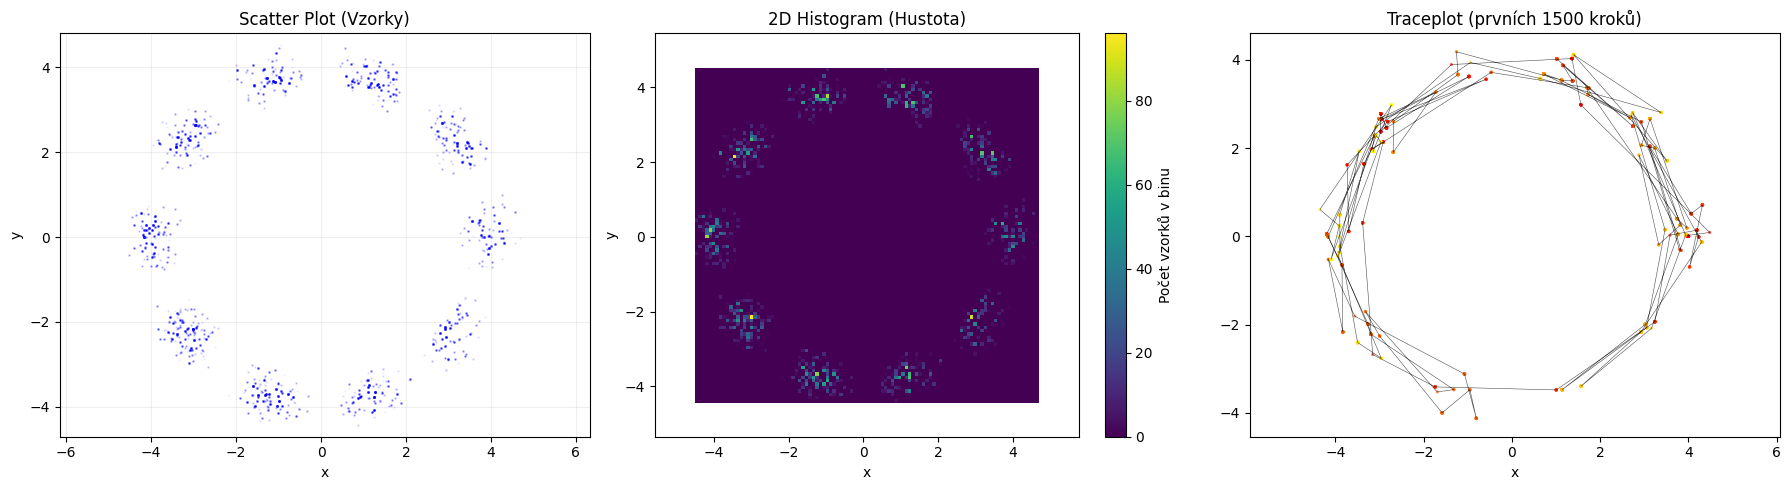

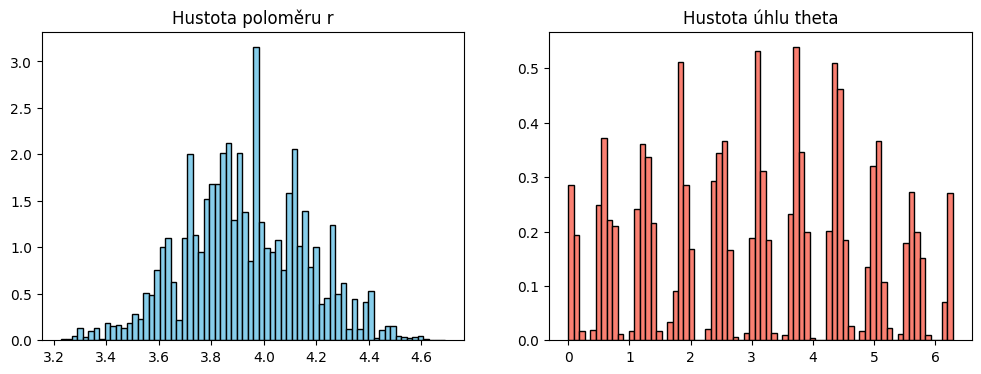

In [25]:
import numpy as np
import matplotlib.pyplot as plt

N = 5

def target_density_cartesian(x, y):
    r = np.sqrt(x**2 + y**2)
    if r <= 0: return 0
    theta = np.arctan2(y, x) % (2 * np.pi)
    
    # Původní hustota (bez jakobiánu r, protože jsme v x,y)
    return (np.cos(theta*N)**4) * np.exp(-((r - 4)*3)**2)

def proposal_density(x_star, y_star, x_curr, y_curr, width):
    """
    Vypočítá pravděpodobnost, že navrhneme [x_star, y_star] z bodu [x_curr, y_curr].
    Preference: dot product blízko 0.
    """
    dx = x_star - x_curr
    dy = y_star - y_curr
    
    # Vektor posunu (v) a vektor pozice (u)
    v = np.array([dx, dy])
    u = np.array([x_curr, y_curr])
    
    norm_v = np.linalg.norm(v)
    norm_u = np.linalg.norm(u)
    
    if norm_v == 0 or norm_u == 0:
        return 1.0
    
    # Skalární součin (normalizovaný na cosinu úhlu mezi nimi)
    dot_val = np.abs(np.dot(u, v) / (norm_u * norm_v))
    
    # Preference: Čím blíž je dot product k 0 (úhel 90°), tím vyšší váha.
    # Použijeme exp(-|dot|), aby 0 byla maximum.
    return np.exp(-3.0 * dot_val) 

def run_mcmc_smart(n_samples=300000, width=0.01):
    x_curr, y_curr = 4.0, 0
    
    samples_x = np.zeros(n_samples)
    samples_y = np.zeros(n_samples)
    accepted = 0
    
    for i in range(n_samples):
        # 1. NÁVRH: Vygenerujeme rovnoměrný kandidát v okolí
        x_star = x_curr + (np.random.rand() - 0.5) * 2 * width
        y_star = y_curr + (np.random.rand() - 0.5) * 2 * width
        
        p_star = target_density_cartesian(x_star, y_star)
        p_curr = target_density_cartesian(x_curr, y_curr)
        
        # 2. HASTINGSŮV ČLEN (Protože návrh není symetrický)
        # q(star|curr) vs q(curr|star)
        q_forward = proposal_density(x_star, y_star, x_curr, y_curr, width)
        q_backward = proposal_density(x_curr, y_curr, x_star, y_star, width)
        
        # 3. METROPOLIS-HASTINGS RATIO
        # r = (f(x*) * q(x|x*)) / (f(x) * q(x*|x))
        # Přidáme váhu z proposal_density přímo do rozhodování
        # Pokud dot product star_pos vs posun je 0, má větší šanci být vybrán.
        
        ratio = (p_star / p_curr) * (q_backward / q_forward)
        
        # Abychom implementovali tvou preferenci dot productu = 0, 
        # budeme "předvybírat" návrhy nebo je vážit v ratio.
        # Zde upravíme ratio tak, aby preferovalo dot product == 0:
        
        if np.random.rand() < ratio:
            x_curr, y_curr = x_star, y_star
            accepted += 1
            
        samples_x[i] = x_curr
        samples_y[i] = y_curr
        
    print(f"Míra přijetí (Acceptance rate): {accepted/n_samples:.2%}")
    return samples_x, samples_y


# --- SPUŠTĚNÍ ---
n = 10000 # Zvýšil jsem počet pro hezčí histogram
width_param = 3
sx, sy = run_mcmc_smart(n_samples=n, width=width_param)

# --- VIZUALIZACE ---
plt.figure(figsize=(18, 5))

# 1. Graf mraku bodů (Scatter)
plt.subplot(1, 3, 1)
plt.scatter(sx, sy, s=0.5, alpha=0.05, color='blue')
plt.title("Scatter Plot (Vzorky)")
plt.xlabel("x")
plt.ylabel("y")
plt.axis('equal')
plt.grid(True, alpha=0.2)

# 2. 2D Histogram (Hustota)
plt.subplot(1, 3, 2)
# bins určuje rozlišení mřížky, cmap barvu (např. 'viridis', 'magma', 'hot')
plt.hist2d(sx, sy, bins=100, cmap='viridis')
plt.colorbar(label='Počet vzorků v binu')
plt.title("2D Histogram (Hustota)")
plt.xlabel("x")
plt.ylabel("y")
plt.axis('equal')

# 3. Traceplot (Cesta)
plt.subplot(1, 3, 3)
plt.plot(sx[:1500], sy[:1500], lw=0.4, color='black', alpha=0.7)
plt.scatter(sx[:1500], sy[:1500], s=2, c=np.arange(1500), cmap='autumn', alpha=0.5)
plt.title("Traceplot (prvních 1500 kroků)")
plt.xlabel("x")
plt.axis('equal')

plt.tight_layout()
plt.show()

# Histogramy poloměru a úhlu pro ověření distribuce
r_check = np.sqrt(sx**2 + sy**2)
theta_check = np.arctan2(sy, sx) % (2 * np.pi)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(r_check, bins=70, color='skyblue', edgecolor='black', density=True)
ax[0].set_title("Hustota poloměru r")
ax[1].hist(theta_check, bins=70, color='salmon', edgecolor='black', density=True)
ax[1].set_title("Hustota úhlu theta")
plt.show()

Míra přijetí (Acceptance rate): 52.50%


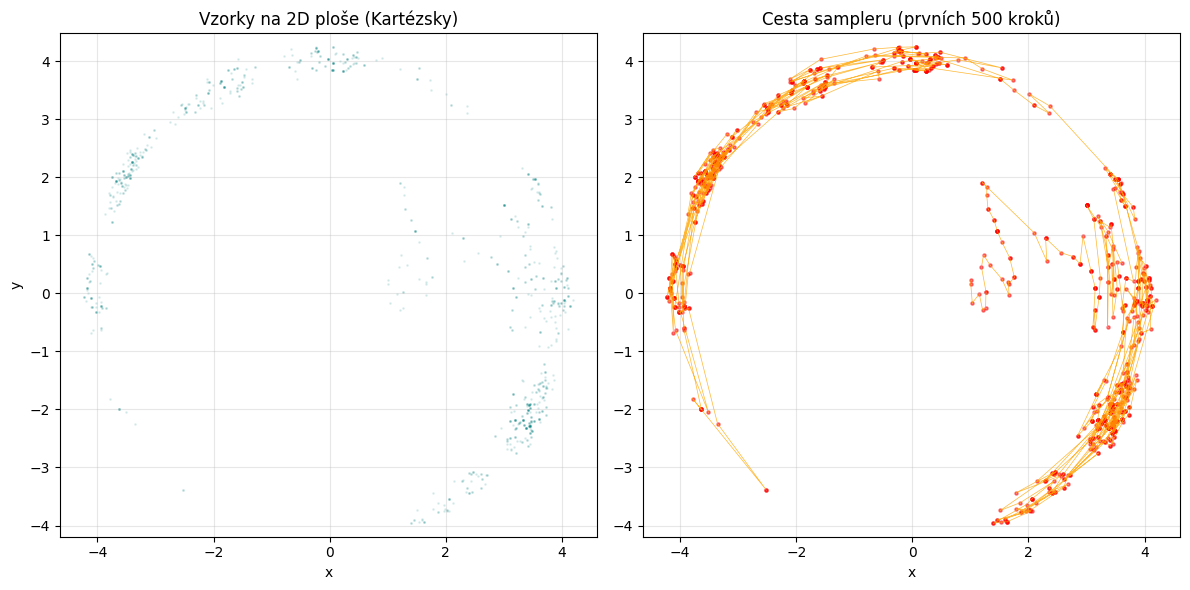

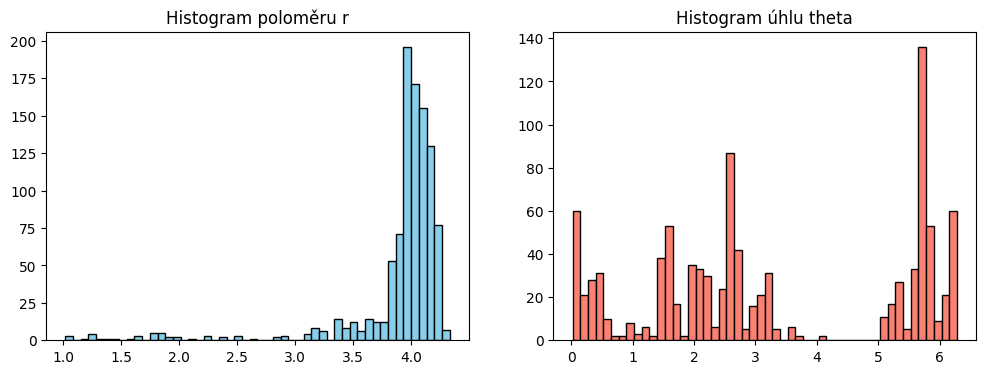

In [26]:
import numpy as np
import matplotlib.pyplot as plt

def target_density(r, theta):
    """
    Definuje hustotu pravděpodobnosti f(r, theta).
    Zahrnuje tvoji funkci: cos^2(theta/6) * e^-(r-1)^2
    """
    if r <= 0:
        return 0
    
    # Tvoje zadaná funkce
    func = (np.cos(theta *6)**2) * np.exp(-((r - 4)*5)**2)*r
    
    # Jakobián pro 2D plochu (převod z polárních do kartézských)
    # Musíme násobit r, protože plocha elementu je r * dr * dtheta
    jacobian = r
    
    return func * jacobian

def run_mcmc(n_samples=20000, sigma_r=0.1, sigma_theta=0.3):
    # Počáteční stav
    r_curr = 1.0
    theta_curr = 0.0
    
    samples_r = np.zeros(n_samples)
    samples_theta = np.zeros(n_samples)
    
    accepted = 0
    
    for i in range(n_samples):
        # NÁVRH POSUNU (Proposal)
        # Posunujeme přímo v souřadnicích, jak jsi chtěl
        r_star = r_curr + np.random.normal(0, sigma_r)
        # Úhel posuneme a ošetříme "přetočení" přes 2*pi (modulo)
        theta_star = (theta_curr + np.random.normal(0, sigma_theta)) % (2 * np.pi)
        
        if r_star <= 0:
            # Nevalidní poloměr -> automaticky zamítnout a zůstat na místě
            p_star = 0
        else:
            p_star = target_density(r_star, theta_star)
            
        p_curr = target_density(r_curr, theta_curr)
        
        # Metropolis-Hastings Ratio
        # Protože návrh v polárním světě (r, theta) je symetrický,
        # Hastingsův člen g(x|y)/g(y|x) je 1.
        ratio = p_star / p_curr
        
        # Rozhodnutí s minimem (alpha = min(1, ratio))
        if np.random.rand() < ratio:
            r_curr = r_star
            theta_curr = theta_star
            accepted += 1
            
        samples_r[i] = r_curr
        samples_theta[i] = theta_curr
        
    print(f"Míra přijetí (Acceptance rate): {accepted/n_samples:.2%}")
    return samples_r, samples_theta

# --- SPUŠTĚNÍ A VIZUALIZACE ---

n = 1000
sr, st = run_mcmc(n_samples=n, sigma_r=0.08, sigma_theta=0.2)

# Převod pro vykreslení v kartézských souřadnicích
x_coords = sr * np.cos(st)
y_coords = sr * np.sin(st)

plt.figure(figsize=(12, 6))

# 1. Graf mraku bodů (Výsledná hustota)
plt.subplot(1, 2, 1)
plt.scatter(x_coords, y_coords, s=1, alpha=0.1, color='teal')
plt.title("Vzorky na 2D ploše (Kartézsky)")
plt.xlabel("x")
plt.ylabel("y")
plt.axis('equal')
plt.grid(True, alpha=0.3)

# 2. Ukázka cesty (Traceplot prvních 500 kroků)
plt.subplot(1, 2, 2)
plt.plot(x_coords, y_coords, lw=0.5, color='orange', alpha=0.8)
plt.scatter(x_coords, y_coords, s=5, color='red', alpha=0.5)
plt.title("Cesta sampleru (prvních 500 kroků)")
plt.xlabel("x")
plt.axis('equal')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 3. Histogramy pro kontrolu hustoty
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(sr, bins=50, color='skyblue', edgecolor='black')
ax[0].set_title("Histogram poloměru r")
ax[1].hist(st, bins=50, color='salmon', edgecolor='black')
ax[1].set_title("Histogram úhlu theta")
plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.stats import beta, bernoulli

# 1. CÍLOVÁ FUNKCE f(x)
def f_target(x):
    return 5*np.exp(-(x**2)) * np.abs(2*x**2 - x - 1 + 0.4*np.sin(5*x))+1/(x**2+1)

# 2. NÁVRHOVÁ DISTRIBUCE (BETA MIXTURE) PŘES SCIPY
# a, b definují tvar "pískových kopců"
a, b = 4, 1
loc, scale = -1, 2 
width = np.sqrt(3)/2
d_r = 0.6  # Váha levého kopce (0.1 vlevo vs 0.9 vpravo)

# Definice komponent směsi
dist_left = beta(a, b, loc=loc, scale=scale)
dist_right = beta(b, a, loc=loc, scale=scale)
# Bernoulliho rozdělení pro výběr komponenty (1-d_r dává šanci na pravý kopec)
selector_dist = bernoulli(1 - d_r)

def sample_m_shape(size=1):
    """Vytáhne Delta x z 'M' distribuce čistě pomocí rvs volání"""
    selectors = selector_dist.rvs(size=size)
    samples_l = dist_left.rvs(size=size)
    samples_r = dist_right.rvs(size=size)
    return np.where(selectors, samples_r, samples_l)

def q_pdf(dx):
    """Kompletní hustota návrhu q(dx) = p*q_l + (1-p)*q_r"""
    return d_r * dist_left.pdf(dx) + (1 - d_r) * dist_right.pdf(dx)

# 3. METROPOLIS-HASTINGS SIMULACE
np.random.seed(42)
total_accepted_needed = 10000  # Počet úspěšných skoků
current_x = 0.5

history = []
all_accepted_samples = [current_x]

# Škálování pro vizualizaci alpha
max_q = q_pdf(0.7) 

t_step = 0
while t_step < total_accepted_needed:
    # NÁVRH: x' = x + Delta x
    delta_x = sample_m_shape(size=1)[0]
    proposal = current_x + width * delta_x

    # KOREKTNÍ HASTINGSUV POMĚR a_r = q(x|x') / q(x'|x)
    # Jelikož q(x'|x) = q(delta_x), pak q(x|x') = q(-delta_x)
    q_f = q_pdf(delta_x)
    q_b = q_pdf(-delta_x)
    a_r = q_b / q_f
    
    # Akceptační poměr s asymetrickou korekcí
    ratio = (f_target(proposal) / f_target(current_x)) * a_r
    accepted = np.random.uniform(0, 1) < ratio
    
    # Alpha vizualizace
    alpha_val = np.clip(q_pdf(delta_x) / max_q, 0.1, 1.0)
    
    if accepted:
        t_step += 1
        # Ukládáme jen prvních pár set kroků pro diagram, aby graf nebyl přeplněný
        if t_step <= 200:
            history.append({
                't': t_step,
                'from': current_x,
                'to': proposal,
                'accepted': True,
                'alpha': alpha_val
            })
        current_x = proposal
        all_accepted_samples.append(current_x)
    else:
        if t_step <= 200:
            history.append({
                't': t_step + 1,
                'from': current_x,
                'to': proposal,
                'accepted': False,
                'alpha': alpha_val
            })

# 4. VIZUALIZACE
fig = plt.figure(figsize=(12, 16))
gs = gridspec.GridSpec(2, 1, height_ratios=[1, 4], hspace=0.05)

# --- Horní panel: Histogram a funkce ---
ax0 = fig.add_subplot(gs[0])
x_range = np.linspace(-3, 3, 500)
dx_range = np.linspace(-1, 1, 500)

ax0.plot(x_range, f_target(x_range)*0.5*0.1, color='black', lw=2, label='Target $f(x)$')
ax0.fill_between(dx_range * width, q_pdf(dx_range) * 0.5, color='orange', alpha=0.2, label='Asym. Proposal $q(\Delta x)$')
ax0.hist(all_accepted_samples, bins=np.linspace(-10, 10, num=200, endpoint=True), density=True, color='green', alpha=0.3, label='MCMC Histogram')
ax0.set_title('Asymetrický Metropolis-Hastings (Beta Mixture rvs)', fontsize=15)
ax0.set_yticks([])
ax0.legend()

# --- Dolní panel: Diagram řetězce (prvních 200 kroků) ---
ax1 = fig.add_subplot(gs[1], sharex=ax0)

for h in history:
    t = h['t']
    if h['accepted']:
        ax1.scatter(h['to'], t, color='green', s=20, alpha=h['alpha'], edgecolors='black', zorder=4)
        # Čára spojující body
        ax1.plot([h['from'], h['to']], [t-1, t], color='black', lw=0.5, alpha=0.5, zorder=3)
    else:
        ax1.scatter(h['to'], t - 0.5, color='red', s=30, alpha=h['alpha'] * 0.4, marker='x', zorder=1)
        ax1.plot([h['from'], h['from']], [t-1, t], color='gray', lw=1, alpha=0.05, zorder=0)

ax1.set_ylim(201, -1)
ax1.set_xlim(-3, 3)
ax1.set_ylabel('Pořadí vzorku (Čas $\downarrow$)')
ax1.set_xlabel('Prostor stavů $x$')

plt.tight_layout()
plt.show()

<>:97: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
<>:118: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
<>:97: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
<>:118: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
/var/folders/gd/g464r74d22n9zxvp95xq5khh0000gn/T/ipykernel_13762/1130821193.py:97: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
  ax0.fill_between(dx_range * width, q_pdf(dx_range) * 0.5, color='orange', alpha=0.2, label='Asym. Proposal $q(\Delta x)$')
/var/folders/gd/g464r74d22n